In [ ]:
# Notes
# - T-SNE needs a larger feature set to visualise the 2d seperaton of llms over more factors
# - 
# -

# Gap plot across llm and workloads:

C:\Users\AS9Wa\AppData\Local\Temp\ipykernel_584\942167515.py:141: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap("tab10", len(llms))


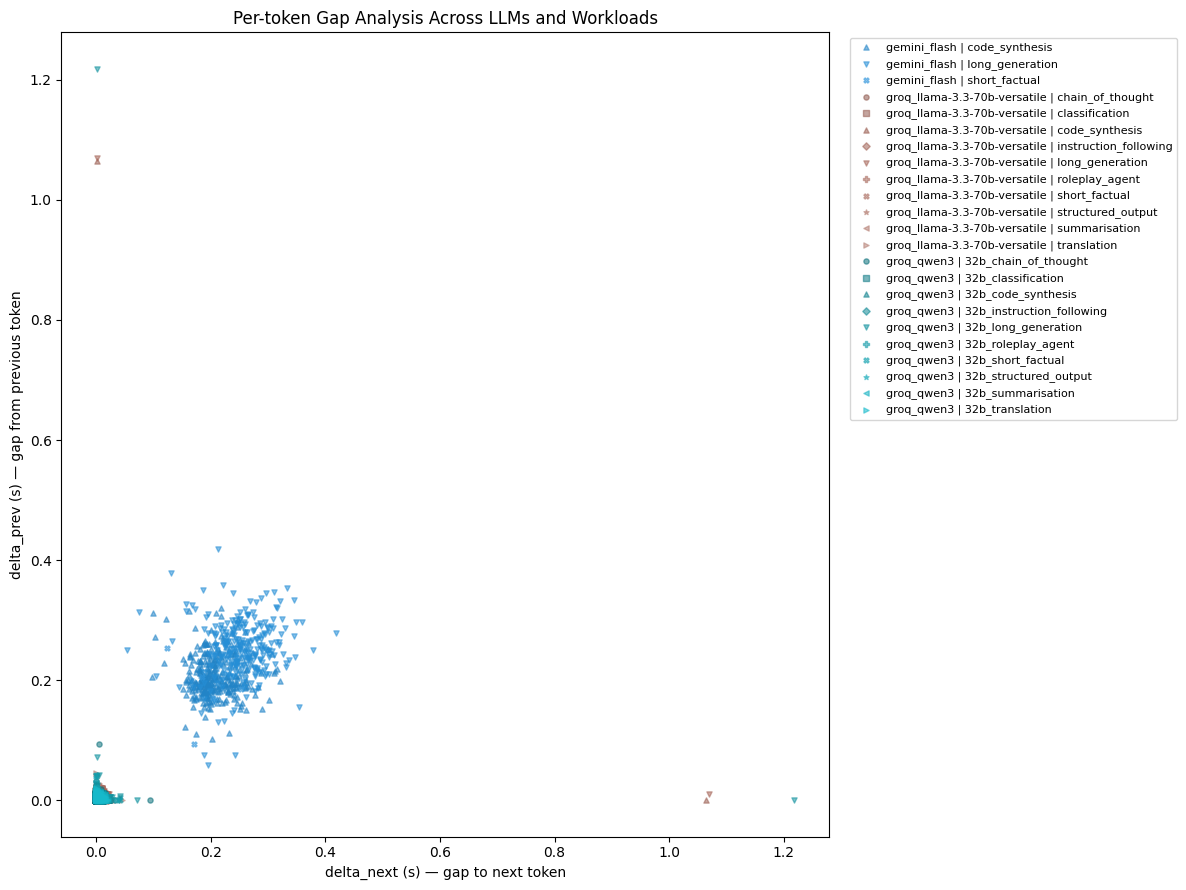

In [2]:
import os
import re
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================

# Folder containing *.tokens.json files
TOKEN_DIR = Path("../Datastore/raw_captures")

# Optional:
# Save figure instead of showing interactively
SAVE_FIGURE = False
OUTPUT_FILE = "token_gap_scatter.png"


# ============================================================
# FILE PARSING
# ============================================================

# Example filename:
# 20260508T214145Z_groq_llama-3.3-70b-versatile_code_synthesis_96b953f4.tokens.json

FILENAME_PATTERN = re.compile(
    r"""
    (?P<timestamp>[^_]+)_
    (?P<llm>[^_]+_[^_]+)_
    (?P<workload>[^_]+(?:_[^_]+)*)_
    (?P<id>[a-f0-9]+)
    \.tokens\.json$
    """,
    re.VERBOSE,
)


def parse_filename(filename):
    """
    Extract llm and workload from filename.
    """

    m = FILENAME_PATTERN.match(filename)

    if not m:
        print(f"Skipping unrecognized filename: {filename}")
        return None

    return {
        "timestamp": m.group("timestamp"),
        "llm": m.group("llm"),
        "workload": m.group("workload"),
        "id": m.group("id"),
    }


# ============================================================
# LOAD + AGGREGATE DATA
# ============================================================

all_points = []

token_files = sorted(Path(TOKEN_DIR).glob("*.tokens.json"))

if not token_files:
    raise FileNotFoundError(f"No *.tokens.json files found in {TOKEN_DIR}")

for token_file in token_files:

    meta = parse_filename(token_file.name)

    if meta is None:
        continue

    with open(token_file, "r") as f:
        tokens = json.load(f)

    # Keep only tokens with both gaps available
    filtered = [
        t for t in tokens
        if t.get("delta_prev") is not None
        and t.get("delta_next") is not None
    ]

    if not filtered:
        continue

    d_prev = np.array([t["delta_prev"] for t in filtered])
    d_next = np.array([t["delta_next"] for t in filtered])

    for x, y in zip(d_next, d_prev):
        all_points.append({
            "x": x,
            "y": y,
            "llm": meta["llm"],
            "workload": meta["workload"],
        })


import matplotlib.colors as mcolors
from colorsys import rgb_to_hls, hls_to_rgb


# ============================================================
# COLOR SHADE HELPER
# ============================================================

def adjust_lightness(color, amount=1.0):
    """
    amount < 1  -> darker
    amount > 1  -> lighter
    """
    try:
        c = mcolors.cnames[color]
    except Exception:
        c = color

    r, g, b = mcolors.to_rgb(c)
    h, l, s = rgb_to_hls(r, g, b)

    l = max(0, min(1, amount * l))

    r, g, b = hls_to_rgb(h, l, s)

    return (r, g, b)


# ============================================================
# PLOTTING
# ============================================================

fig, ax = plt.subplots(figsize=(12, 9))

llms = sorted(set(p["llm"] for p in all_points))
workloads = sorted(set(p["workload"] for p in all_points))

# Base colormap for LLMs
base_cmap = plt.cm.get_cmap("tab10", len(llms))

base_colors = {
    llm: base_cmap(i)
    for i, llm in enumerate(llms)
}

# Different shades for workloads
shade_levels = np.linspace(0.6, 1.4, len(workloads))

markers = [
    "o", "s", "^", "D", "v", "P", "X", "*", "<", ">"
]

workload_marker_map = {
    workload: markers[i % len(markers)]
    for i, workload in enumerate(workloads)
}

for llm in llms:

    base_color = base_colors[llm]

    for i, workload in enumerate(workloads):

        subset = [
            p for p in all_points
            if p["llm"] == llm and p["workload"] == workload
        ]

        if not subset:
            continue

        x = [p["x"] for p in subset]
        y = [p["y"] for p in subset]

        # Shade variation
        color = adjust_lightness(
            base_color,
            shade_levels[i]
        )

        ax.scatter(
            x,
            y,
            alpha=0.55,
            s=14,
            marker=workload_marker_map[workload],
            color=color,
            label=f"{llm} | {workload}",
        )


# ============================================================
# LABELS
# ============================================================

ax.set_xlabel("delta_next (s) — gap to next token")
ax.set_ylabel("delta_prev (s) — gap from previous token")
ax.set_title("Per-token Gap Analysis Across LLMs and Workloads")

handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))

ax.legend(
    unique.values(),
    unique.keys(),
    fontsize=8,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    
)

plt.tight_layout()

if SAVE_FIGURE:
    plt.savefig(OUTPUT_FILE, dpi=300, bbox_inches="tight")
    print(f"Saved figure to: {OUTPUT_FILE}")
else:
    plt.show()

# T-SNE PLOT:

Feature matrix shape: (100, 29)


C:\Users\AS9Wa\AppData\Local\Temp\ipykernel_584\2245080397.py:167: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(llms))


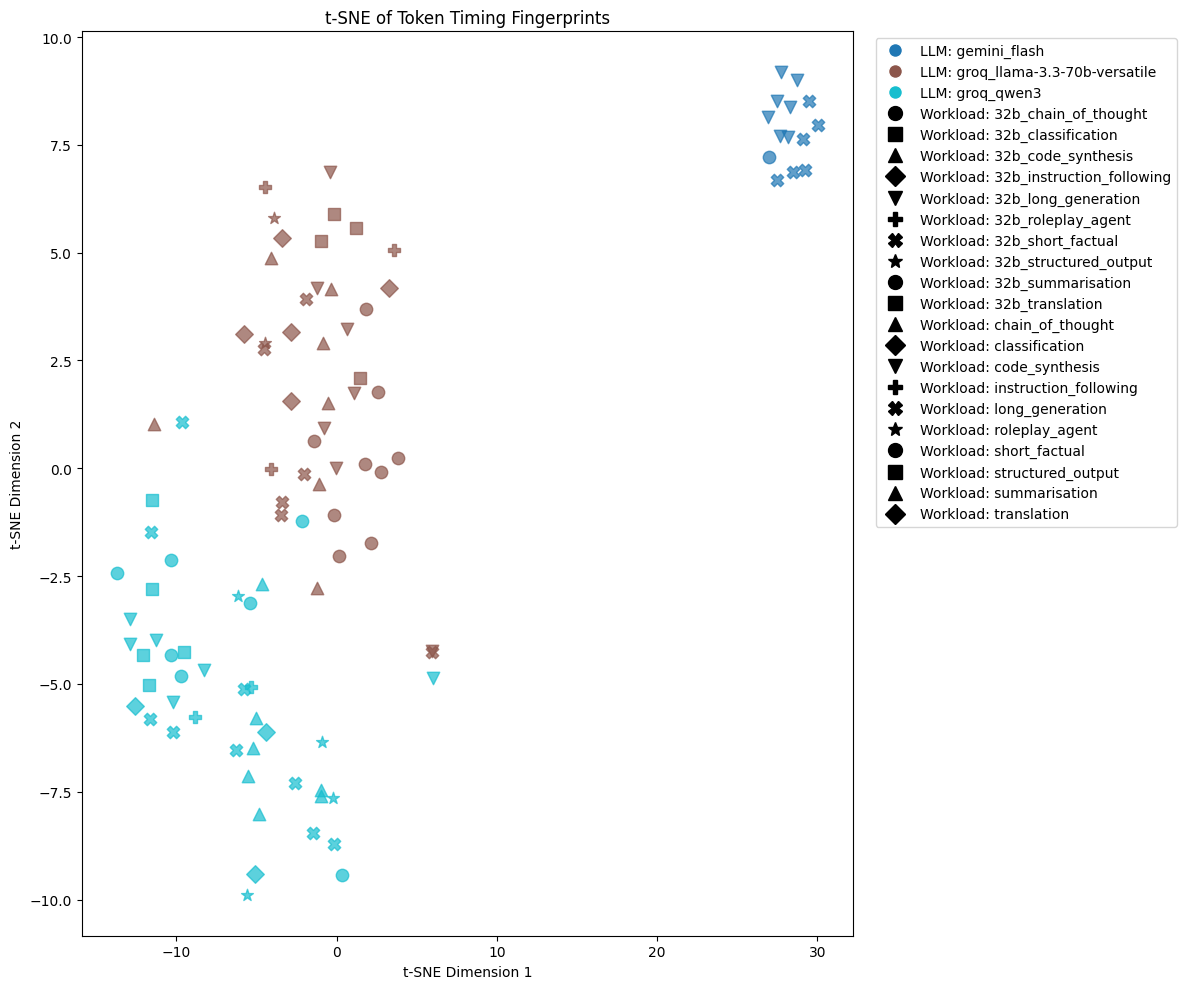

In [3]:
import re
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler


# ============================================================
# CONFIG
# ============================================================

TOKEN_DIR = Path("../Datastore/raw_captures")

# ============================================================
# FILENAME PARSING
# ============================================================

FILENAME_PATTERN = re.compile(
    r"""
    (?P<timestamp>[^_]+)_
    (?P<llm>[^_]+_[^_]+)_
    (?P<workload>.+?)_
    (?P<id>[a-f0-9]+)
    \.tokens\.json$
    """,
    re.VERBOSE,
)


def parse_filename(filename):

    m = FILENAME_PATTERN.match(filename)

    if not m:
        return None

    return {
        "llm": m.group("llm"),
        "workload": m.group("workload"),
    }


# ============================================================
# FEATURE EXTRACTION
# ============================================================

def build_fingerprint(tokens):
    """
    Convert token timing trace into fixed-length vector.
    """

    gaps = np.array([
        t["delta_prev"]
        for t in tokens
        if t.get("delta_prev") is not None
    ])

    if len(gaps) < 5:
        return None

    # --------------------------------------------------------
    # Statistical features
    # --------------------------------------------------------

    features = []

    features.extend([
        np.mean(gaps),
        np.std(gaps),
        np.min(gaps),
        np.max(gaps),
        np.median(gaps),
        np.percentile(gaps, 25),
        np.percentile(gaps, 75),
        np.percentile(gaps, 90),
        np.percentile(gaps, 95),
    ])

    # --------------------------------------------------------
    # Histogram fingerprint
    # --------------------------------------------------------

    hist, _ = np.histogram(
        gaps,
        bins=20,
        range=(0, np.percentile(gaps, 99)),
        density=True,
    )

    features.extend(hist)

    return np.array(features)


# ============================================================
# LOAD DATA
# ============================================================

X = []
labels = []

token_files = sorted(TOKEN_DIR.glob("*.tokens.json"))

for token_file in token_files:

    meta = parse_filename(token_file.name)

    if meta is None:
        continue

    with open(token_file, "r") as f:
        tokens = json.load(f)

    fp = build_fingerprint(tokens)

    if fp is None:
        continue

    X.append(fp)

    labels.append({
        "llm": meta["llm"],
        "workload": meta["workload"],
    })

X = np.array(X)

print("Feature matrix shape:", X.shape)

# ============================================================
# NORMALIZE
# ============================================================

X_scaled = StandardScaler().fit_transform(X)

# ============================================================
# t-SNE
# ============================================================

tsne = TSNE(
    n_components=2,
    perplexity=15,
    learning_rate="auto",
    init="pca",
    random_state=42,
)

X_tsne = tsne.fit_transform(X_scaled)

# ============================================================
# PLOTTING
# ============================================================

fig, ax = plt.subplots(figsize=(12, 10))

llms = sorted(set(x["llm"] for x in labels))
workloads = sorted(set(x["workload"] for x in labels))

# ------------------------------------------------------------
# Base colors per LLM
# ------------------------------------------------------------

cmap = plt.cm.get_cmap("tab10", len(llms))

llm_colors = {
    llm: cmap(i)
    for i, llm in enumerate(llms)
}

# ------------------------------------------------------------
# Marker per workload
# ------------------------------------------------------------

markers = ["o", "s", "^", "D", "v", "P", "X", "*"]

workload_markers = {
    workload: markers[i % len(markers)]
    for i, workload in enumerate(workloads)
}

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

for i, point in enumerate(X_tsne):

    llm = labels[i]["llm"]
    workload = labels[i]["workload"]

    ax.scatter(
        point[0],
        point[1],
        color=llm_colors[llm],
        marker=workload_markers[workload],
        s=80,
        alpha=0.7,
    )

# ------------------------------------------------------------
# Custom legend
# ------------------------------------------------------------

from matplotlib.lines import Line2D

legend_elements = []

# LLM color legend
for llm in llms:
    legend_elements.append(
        Line2D(
            [0],
            [0],
            marker='o',
            color='w',
            label=f"LLM: {llm}",
            markerfacecolor=llm_colors[llm],
            markersize=10,
        )
    )

# workload marker legend
for workload in workloads:
    legend_elements.append(
        Line2D(
            [0],
            [0],
            marker=workload_markers[workload],
            color='black',
            label=f"Workload: {workload}",
            linestyle='None',
            markersize=10,
        )
    )

ax.legend(
    handles=legend_elements,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

ax.set_title("t-SNE of Token Timing Fingerprints")
ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")

plt.tight_layout()
plt.show()